<a href="https://colab.research.google.com/github/naugim26/2026-BDA/blob/main/projects/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 과제1: 지정 데이터(titanic1309.csv) 분석: 타이타닉호 데이터 분석

### 1. 라이브러리 로드와 데이터 확인
### 2. 데이터 정제
### 3. 분석
### 4. 데이터 시각화
### 5. 결론 도출

# 1.라이브러리 로드와 데이터 확인

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 52.3 MB/s eta 0:00:00


In [9]:
tt = pd.read_csv("/content/titanic1309.csv")

# 가장 앞 열에 중복된 값이 없는지 고유성을 확인
print(tt.iloc[:, 0].is_unique)

# 가장 앞 열에 비어 있는 값(결측치)이 없는지 확인
print(tt.iloc[:, 0].isnull().sum())

True
0


In [5]:
# 1. 데이터의 크기 및 상위 5개 행 확인
print("=== 데이터 구조 및 상위 행 확인 ===")
print(f"전체 데이터 행 수: {tt.shape[0]}, 열 수: {tt.shape[1]}")
display(tt.head())

=== 데이터 구조 및 상위 행 확인 ===
전체 데이터 행 수: 1309, 열 수: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# 2. 데이터 타입 및 결측치 요약 정보 확인
print("\n=== 데이터 요약 정보 (info) ===")
tt.info()


=== 데이터 요약 정보 (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


### 타이타닉 데이터셋 열(Column) 의미 요약

| 변수명 (Column) | 의미 (Description) | 데이터 타입 | 분석 시 참고 사항 |
| :--- | :--- | :--- | :--- |
| **PassengerId** | 승객 고유 번호 | 정수형 (int64) | 1부터 시작하는 단순 식별자 (분석 대상 제외 추천) |
| **Survived** | 생존 여부 | 정수형 (int64) | **0 = 사망, 1 = 생존** (이번 과제의 핵심 타겟 변수) |
| **Pclass** | 티켓 등급 (클래스) | 정수형 (int64) | **1 = 1등석, 2 = 2등석, 3 = 3등석** (과제의 핵심 분석 초점) |
| **Name** | 승객 이름 | 문자열 (object) | 호칭(Mr, Mrs, Miss 등)을 추출해 사회적 지위나 성별 추정 가능 |
| **Sex** | 성별 | 문자열 (object) | `male`(남성), `female`(여성) / '여성과 아이 먼저' 규칙 확인용 |
| **Age** | 나이 | 실수형 (float64) | **결측치 존재 (263개)** / 평균이나 중앙값으로 대체 필요 |
| **SibSp** | 함께 탑승한 형제자매/배우자 수 | 정수형 (int64) | 가족 동반 여부 파악 가능 (Sibling + Spouse) |
| **Parch** | 함께 탑승한 부모/자녀 수 | 정수형 (int64) | 가족 동반 여부 파악 가능 (Parent + Child) |
| **Ticket** | 티켓 번호 | 문자열 (object) | 알파벳과 숫자가 섞인 고유 티켓 문장 (일반적으로 분석 제외) |
| **Fare** | 여객 운임 (티켓 가격) | 실수형 (float64) | **결측치 존재 (1개)** / Pclass(클래스)와 강한 상관관계를 보임 |
| **Cabin** | 객실 번호 | 문자열 (object) | **결측치 매우 많음 (1014개)** / 선실 위치(A~G 구역) 파악 가능 |
| **Embarked** | 탑승 항구 | 문자열 (object) | **결측치 존재 (2개)** / C = Cherbourg, Q = Queenstown, S = Southampton |

In [7]:
# 분석에 사용할 주요 열들의 고유값(종류) 확인하기

print("1. Pclass(티켓 등급) 종류:")
print(tt['Pclass'].unique())

print("\n2. Survived(생존 여부) 종류:")
print(tt['Survived'].unique())

print("\n3. Sex(성별) 종류:")
print(tt['Sex'].unique())

print("\n4. Embarked(탑승 항구) 종류:")
print(tt['Embarked'].unique())

1. Pclass(티켓 등급) 종류:
[3 1 2]

2. Survived(생존 여부) 종류:
[0 1]

3. Sex(성별) 종류:
['male' 'female']

4. Embarked(탑승 항구) 종류:
['S' 'C' 'Q' nan]


# 데이터 정제
### 결측치 처리

Embarked (탑승 장소) : 범주형 데이터

현황: 1309개 중 2개 누락 (결측치 비율 약 0.15%)

처리 방법: 최빈값 대체

승객의 70% 이상이 S에서 탑승했고, 결측치 비율이 적음

Fare (티켓 요금) : 연속형 숫자 데이터

현황: 1309개 중 1개 누락 (결측치 비율 약 0.07%)

처리 방법: 중앙값(Median) 대체

이 승객이 머문 객실 등급(Pclass)의 요금 중앙값으로 채우기

Age (나이) : 연속형 숫자 데이터

현황: 1309개 중 263개 누락 (결측치 비율 약 20%)

처리 방법: 조건부 평균(Group Mean) 대체법 또는 무작위 추출 대체법

결측치가 많은 편이기 때문에 성별과 객실 등급으로 그룹을 묶어 그룹의 평균 나이로 채우기

Cabin (객실 번호) : 범주형/텍스트 데이터

현황: 1309개 중 1014개 누락 (결측치 비율 약 77.4%)

처리 방법: 결측치 자체를 하나의 새로운 범주('Unknown')로 지정 또는 변수 제거

In [10]:
import pandas as pd

# 데이터 불러오기
tt = pd.read_csv('titanic1309.csv')

print("--- 처리 전 결측치 개수 ---")
print(tt.isnull().sum())

# 1. Embarked: 최빈값(S)으로 대체
most_frequent_embarked = tt['Embarked'].mode()[0]
tt['Embarked'] = tt['Embarked'].fillna(most_frequent_embarked)

# 2. Fare: 객실 등급(Pclass)별 요금의 중앙값으로 세분화해서 대체
tt['Fare'] = tt.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# 3. Age: 성별(Sex)과 객실 등급(Pclass)별 평균 나이로 세분화해서 대체
tt['Age'] = tt.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.mean()))

# 4. Cabin: 결측치가 너무 많으므로 'Unknown'이라는 새로운 범주로 채우기
tt['Cabin'] = tt['Cabin'].fillna('Unknown')

print("\n--- 처리 후 결측치 개수 (전부 0이 되어야 함) ---")
print(tt.isnull().sum())

--- 처리 전 결측치 개수 ---
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

--- 처리 후 결측치 개수 (전부 0이 되어야 함) ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# 분석

### 클래스별로 생존율 계산
### 생존율 계산이 불가능한 변수 4개(PassengerId(번호), Name(이름), Ticket(티켓번호), Cabin(객실 번호)

In [13]:
import pandas as pd

print("=== [그룹 1] 범주형 및 숫자형 변수별 생존율 ===")

print("\n[Pclass별 생존율]")
print(tt.groupby('Pclass')['Survived'].mean())

print("\n[Sex별 생존율]")
print(tt.groupby('Sex')['Survived'].mean())

print("\n[Embarked별 생존율]")
print(tt.groupby('Embarked')['Survived'].mean())

print("\n[SibSp(형제/배우자)별 생존율]")
print(tt.groupby('SibSp')['Survived'].mean())

print("\n[Parch(부모/자녀)별 생존율]")
print(tt.groupby('Parch')['Survived'].mean())

# 나이와 요금은 연속형 데이터이므로 4개 구간으로 자동 분할(qcut/cut)해서 생존율 확인
print("\n[Age(연령대)별 생존율]")
tt['Age_Bin'] = pd.cut(tt['Age'], bins=[0, 12, 19, 35, 60, 100], labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Elderly'])
print(tt.groupby('Age_Bin')['Survived'].mean())

print("\n[Fare(요금구간)별 생존율]")
tt['Fare_Bin'] = pd.qcut(tt['Fare'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
print(tt.groupby('Fare_Bin')['Survived'].mean())

print("-" * 50)

# 2. 생존율 계산이 불가능한 고유 변수들 샘플 확인하기
print("=== [그룹 2] 고유 변수들 형태 확인 (평균 계산 불가능) ===")
print(tt[['PassengerId', 'Name', 'Ticket', 'Cabin']].head(3))

=== [그룹 1] 범주형 및 숫자형 변수별 생존율 ===

[Pclass별 생존율]
Pclass
1    0.575851
2    0.422383
3    0.269394
Name: Survived, dtype: float64

[Sex별 생존율]
Sex
female    0.82618
male      0.12930
Name: Survived, dtype: float64

[Embarked별 생존율]
Embarked
C    0.492593
Q    0.439024
S    0.335153
Name: Survived, dtype: float64

[SibSp(형제/배우자)별 생존율]
SibSp
0    0.334456
1    0.520376
2    0.452381
3    0.250000
4    0.181818
5    0.166667
8    0.111111
Name: Survived, dtype: float64

[Parch(부모/자녀)별 생존율]
Parch
0    0.331337
1    0.547059
2    0.530973
3    0.625000
4    0.333333
5    0.166667
6    0.000000
9    0.500000
Name: Survived, dtype: float64

[Age(연령대)별 생존율]
Age_Bin
Child          0.553191
Teenager       0.419847
Young Adult    0.341632
Adult          0.399390
Elderly        0.272727
Name: Survived, dtype: float64

[Fare(요금구간)별 생존율]
Fare_Bin
Low            0.219585
Medium-Low     0.292835
Medium-High    0.432927
High           0.569659
Name: Survived, dtype: float64
--------------------------------

/tmp/ipykernel_1530/4156505100.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tt.groupby('Age_Bin')['Survived'].mean())
/tmp/ipykernel_1530/4156505100.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tt.groupby('Fare_Bin')['Survived'].mean())


### 변수별 분석

/tmp/ipykernel_1530/1002375437.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=tt, ax=axes[0, 0], palette='Blues_d', ci=None)
/tmp/ipykernel_1530/1002375437.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=tt, ax=axes[0, 0], palette='Blues_d', ci=None)
/tmp/ipykernel_1530/1002375437.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=tt, ax=axes[0, 1], palette='Purples_d', ci=None)
/tmp/ipykernel_1530/1002375437.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', 

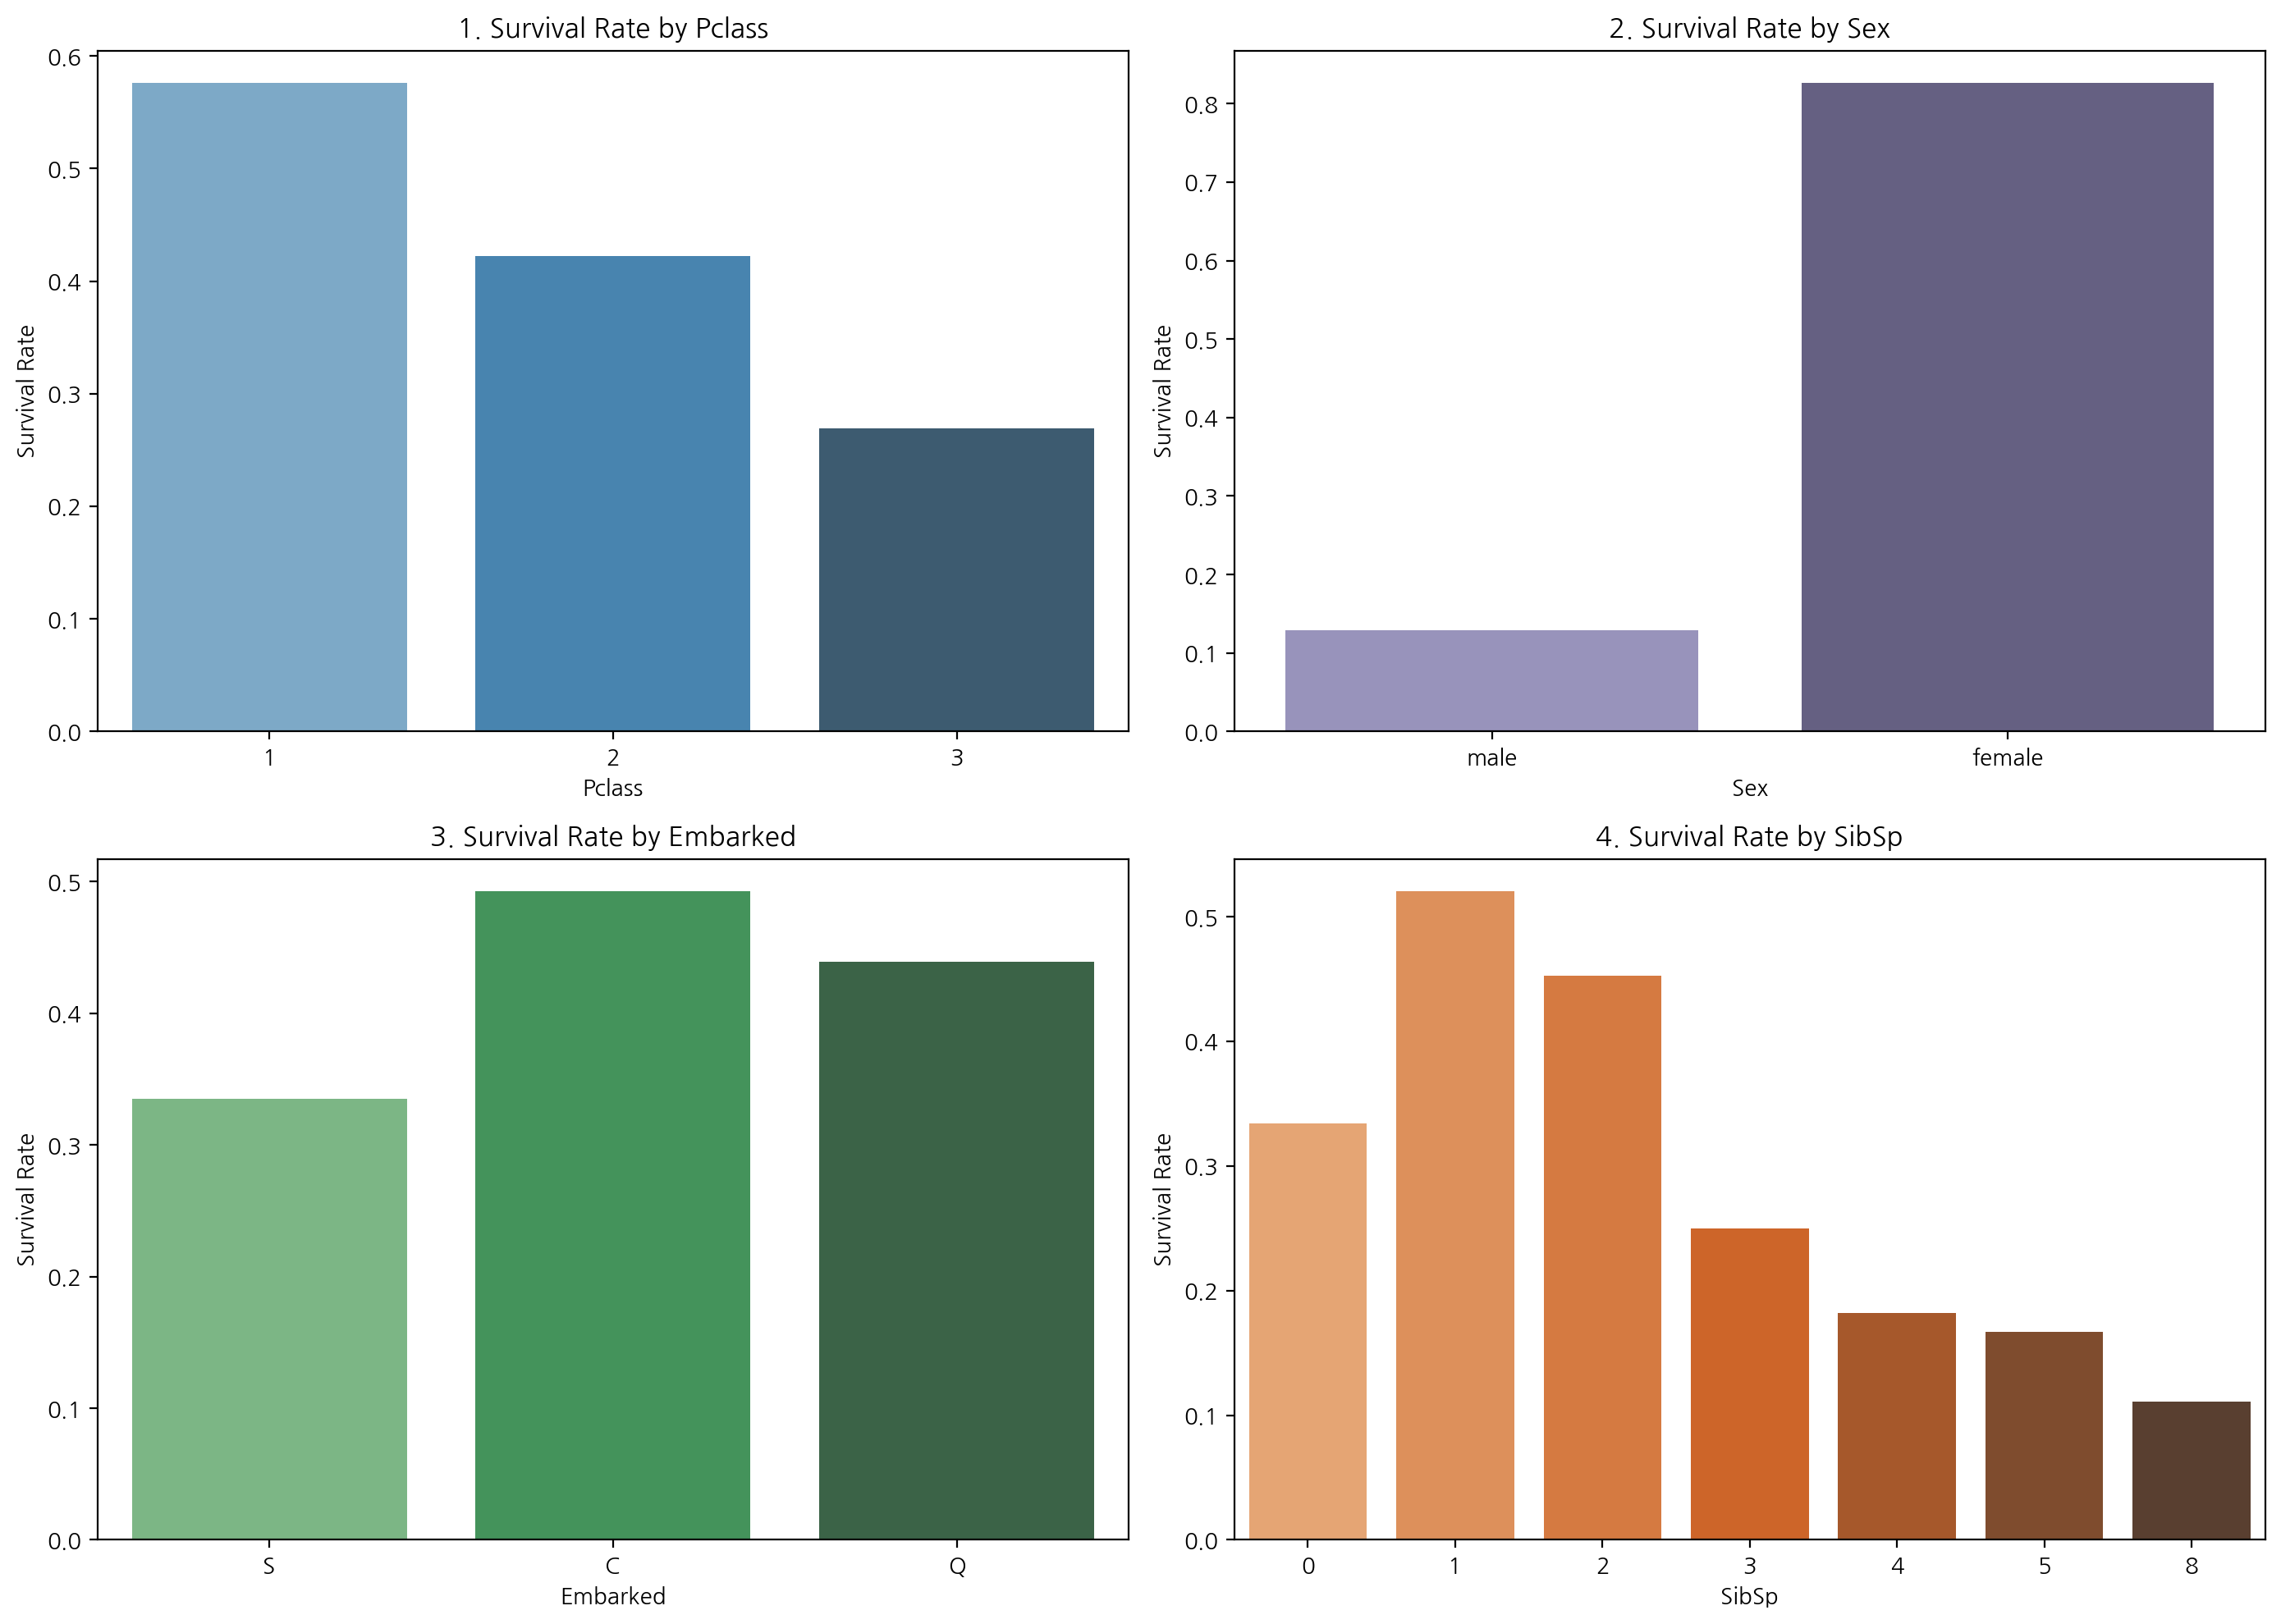

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2행 2열 구조의 서브플롯 틀 만들기 (전체 그래프 크기 가로 14인치, 세로 10인치)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2. [1행 1열] Pclass(객실 등급)별 생존율 그래프
# axes[0, 0] 위치에 시각화 진행 (ci=None으로 신뢰구간 선 제거)
sns.barplot(x='Pclass', y='Survived', data=tt, ax=axes[0, 0], palette='Blues_d', ci=None)
axes[0, 0].set_title('1. Survival Rate by Pclass') # 그래프 제목
axes[0, 0].set_xlabel('Pclass')                    # x축 이름
axes[0, 0].set_ylabel('Survival Rate')             # y축 이름

# 3. [1행 2열] Sex(성별)별 생존율 그래프
# axes[0, 1] 위치에 시각화 진행
sns.barplot(x='Sex', y='Survived', data=tt, ax=axes[0, 1], palette='Purples_d', ci=None)
axes[0, 1].set_title('2. Survival Rate by Sex')
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Survival Rate')

# 4. [2행 1열] Embarked(탑승 장소)별 생존율 그래프
# axes[1, 0] 위치에 시각화 진행
sns.barplot(x='Embarked', y='Survived', data=tt, ax=axes[1, 0], palette='Greens_d', ci=None)
axes[1, 0].set_title('3. Survival Rate by Embarked')
axes[1, 0].set_xlabel('Embarked')
axes[1, 0].set_ylabel('Survival Rate')

# 5. [2행 2열] SibSp(형제자매/배우자 수)별 생존율 그래프
# axes[1, 1] 위치에 시각화 진행
sns.barplot(x='SibSp', y='Survived', data=tt, ax=axes[1, 1], palette='Oranges_d', ci=None)
axes[1, 1].set_title('4. Survival Rate by SibSp')
axes[1, 1].set_xlabel('SibSp')
axes[1, 1].set_ylabel('Survival Rate')

# 6. 그래프 간격이 겹치지 않게 자동으로 최적화해주는 함수
plt.tight_layout()

# 7.최종 그래프 화면 출력
plt.show()

Pclass (객실 등급)별 생존율 분석
분석 결과: 1등실(57.6%), 2등실(42.2%), 3등실(26.9%) 순으로 생존율이 높게 나타남.

객실 등급이 높을수록 생존율이 비례해서 상승함. 이는 높은 등급의 객실이 대피에 유리한 상층부에 위치했거나, 구조 과정에서 우선순위를 얻었을 가능성을 시사함.

Sex (성별)별 생존율 분석
분석 결과: 여성 승객의 생존율은 약 82.6%로 압도적으로 높은 반면, 남성 승객의 생존율은 약 12.9%에 불과함.

해석 (인사이트): 당시 재난 상황에서 "여성과 아이를 먼저 구조한다"는 선박 대피 원칙이 매우 철저하게 지켜졌음을 보여주는 가장 명확한 증거임. 성별은 생존 여부를 가르는 가장 강력한 독립 변수 중 하나임.

Embarked (탑승 장소)별 생존율 분석 (과제 핵심 초점)
분석 결과: C (셰르부르) 탑승자의 생존율이 49.3%로 가장 높고, Q (퀸즈타운)가 43.9%, S (사우샘프턴)가 33.5%로 가장 낮음.

해석 (인사이트): 과제의 초점인 "어디에서 많이 살아남았는가?"에 대한 답으로 C(셰르부르) 탑승자들의 생존율이 가장 높았음을 확인 가능함. 이는 프랑스 부유층이 많이 탑승했던 C 지역 승객 중 높은 등급의 객실(1등실)을 예매한 비율이 높았기 때문으로 추정해 볼 수 있음.

SibSp (형제자매/배우자 수)별 생존율
분석 결과: 혼자 탄 사람(33.4%)보다 1명(52.0%) 또는 2명(45.2%)의 동반자가 있는 경우 생존율이 더 높음. 하지만 3명 이상(대가족)일 경우 생존율이 10~25%대로 급격히 떨어짐.

해석: 적당한 가족 동반은 구조 시 서로를 챙겨 생존에 도움이 되었으나, 가족 구성원이 너무 많으면 대피 지연이나 통제가 어려워 오히려 생존율이 낮아진 것으로 보임.

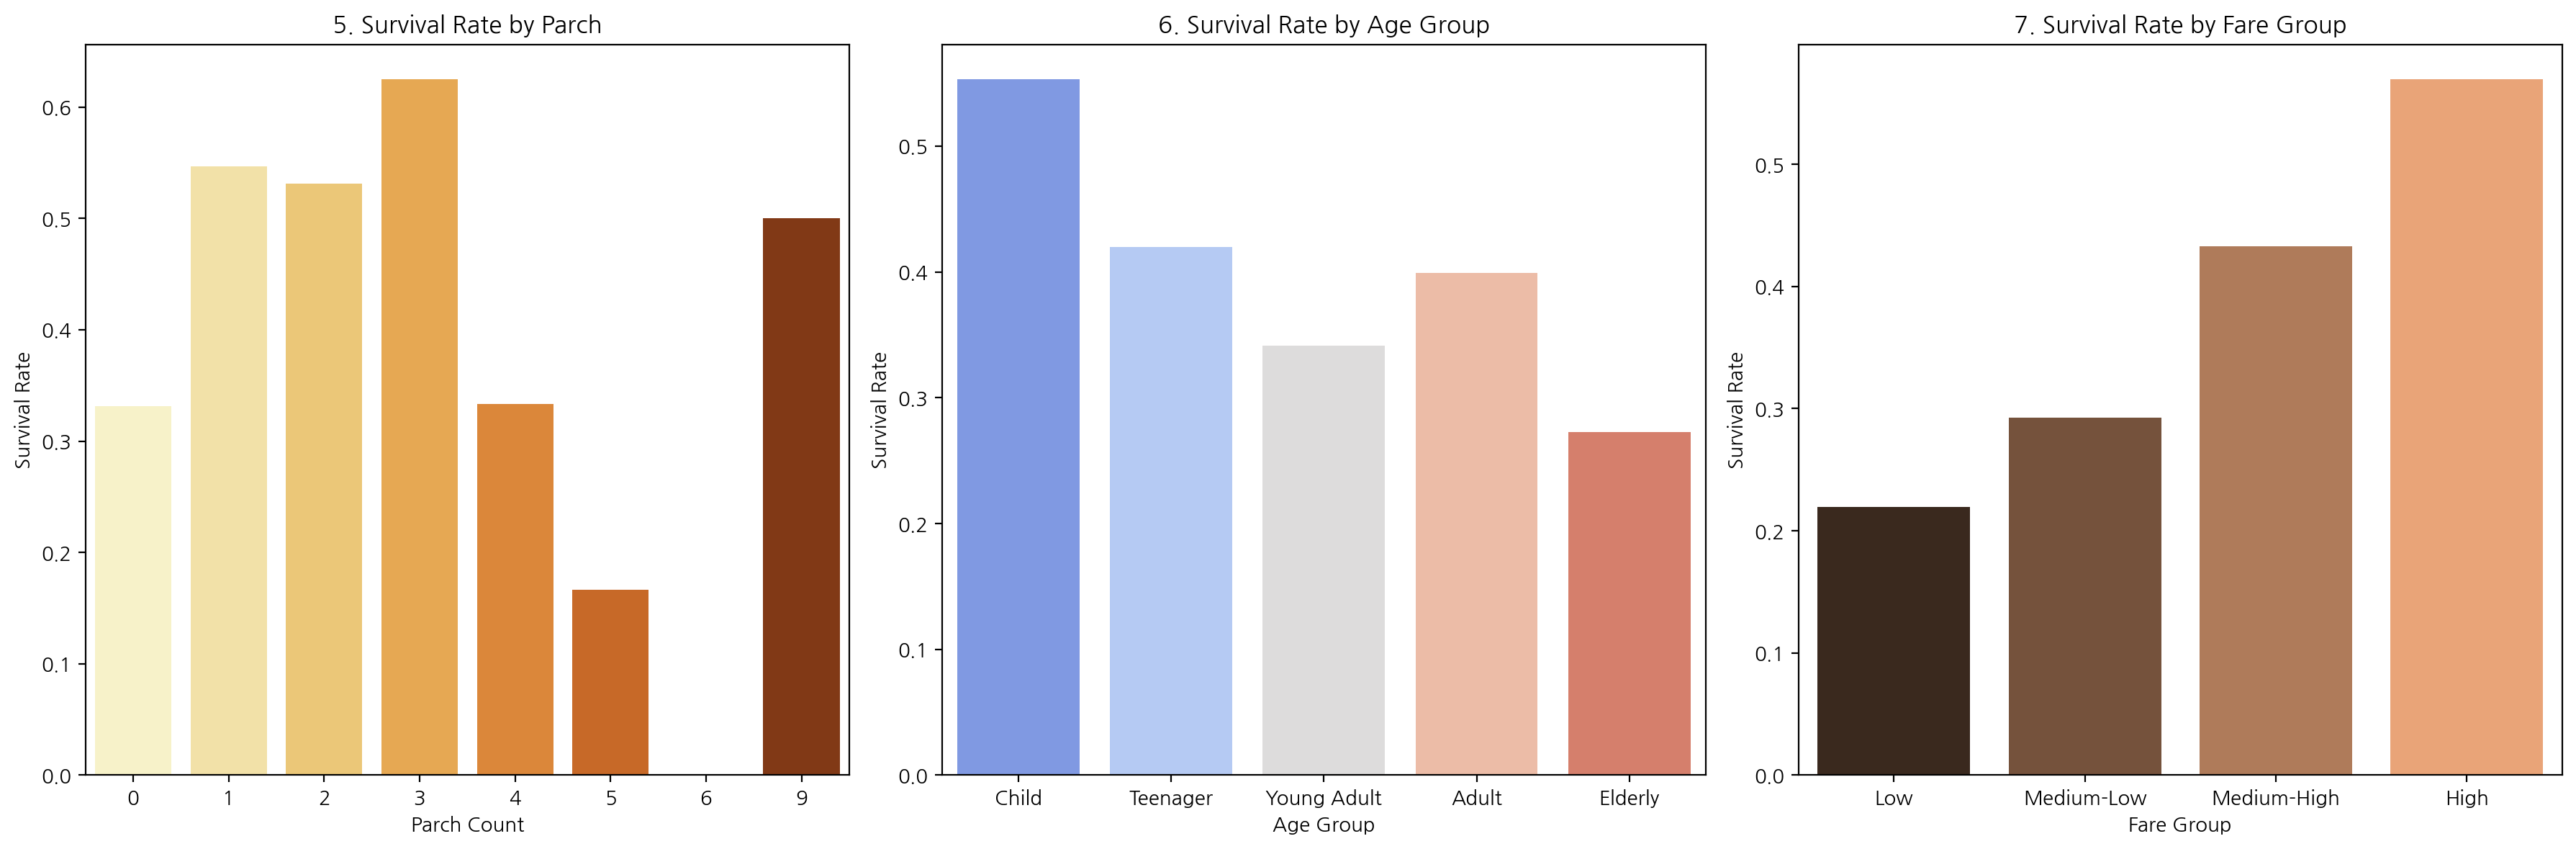

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 화면을 지저분하게 만드는 경고 메시지(Warning) 모두 숨기기
warnings.filterwarnings('ignore')

# 2. 1행 3열 구조의 서브플롯 틀 만들기
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 3. [1열] Parch(부모/자녀 수)별 생존율 그래프
sns.barplot(x='Parch', y='Survived', data=tt, ax=axes[0], palette='YlOrBr', ci=None)
axes[0].set_title('5. Survival Rate by Parch')
axes[0].set_xlabel('Parch Count')
axes[0].set_ylabel('Survival Rate')

# 4. [2열] Age_Bin(연령대)별 생존율 그래프
# 가로축 이름이 명확히 나오도록 x축 데이터 순서를 고정해줬어
sns.barplot(x='Age_Bin', y='Survived', data=tt, ax=axes[1], palette='coolwarm', ci=None,
            order=['Child', 'Teenager', 'Young Adult', 'Adult', 'Elderly'])
axes[1].set_title('6. Survival Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate')

# 5. [3열] Fare_Bin(요금 구간)별 생존율 그래프
# 가로축 요금 순서가 'Low'부터 'High'까지 차례대로 나오도록 고정했어
sns.barplot(x='Fare_Bin', y='Survived', data=tt, ax=axes[2], palette='copper', ci=None,
            order=['Low', 'Medium-Low', 'Medium-High', 'High'])
axes[2].set_title('7. Survival Rate by Fare Group')
axes[2].set_xlabel('Fare Group')
axes[2].set_ylabel('Survival Rate')

# 6. 가로축 글자들이 서로 겹치거나 잘리지 않도록 여백을 넉넉하게 조정
plt.tight_layout()

# 7. 최종 그래프 화면 출력
plt.show()

Parch (부모/자녀 수)별 생존율
분석 결과: 부모/자녀가 1~3명인 경우 생존율이 53% ~ 62.5%로 높은 편임. 반면, 혼자 탄 경우(33.1%)나 4명 이상인 대가족(0% ~ 33.3%)은 생존율이 크게 떨어짐. (9명인 경우 예외적으로 50%가 나오나 샘플 수가 극히 적은 특이치일 가능성이 높음)

해석: 앞서 본 SibSp 변수와 마찬가지로, 재난 상황에서 가족이 적당히 있으면 구조에 서로 도움을 주었으나, 챙겨야 할 가족이 너무 많으면 대피가 지연되어 생존율이 낮아진 것으로 해석됨

Age_Bin (연령대)별 생존율
분석 결과: 어린이(Child)의 생존율이 55.3%로 가장 높고, 노년층(Elderly)의 생존율이 27.3%로 가장 낮음. 10대~성인층은 34% ~ 41% 대의 생존율을 보임.

해석: 성별 분석과 일맥상통하게 "약자인 어린이와 여성을 먼저 구조한다"는 당시의 사회적 합의가 데이터로 증명됨. 체력적으로 대피가 어려웠을 노년층의 생존율이 가장 낮게 나타남.

Fare_Bin (요금 구간)별 생존율
분석 결과: 요금이 가장 저렴한 구간(Low, 21.9%)에서 가장 비싼 구간(High, 56.9%)으로 갈수록 생존율이 계단식으로 완벽하게 상승함.

해석: 요금은 앞서 확인한 Pclass(객실 등급)와 매우 강한 상관관계를 가짐. 비싼 티켓을 산 승객들이 상층부의 좋은 객실을 배정받았고, 이것이 곧 생존율 상승으로 직결되었음을 보여주는 명확한 근거임.